### **Contribution Scores - Locus Plots**

**<span style="color: darkred;">This is notebook 2/2 of the contribution score tracks downstream analyses.</span>**

Contribution scores are generated using the _scripts/chrombpnet_pipeline/3c_ContribsBW.sh_ script

The following script plots regions of interest, including their contribution score tracks and predicted bigwig accessibility tracks.

All contribution score output files are available in:

_/scratch/prj/stem_cells_pituitary/Georgia/ChromBPNet/outputs/(cohort)/(name)/contribs_bw/_

All predicted accessibility tracks are available in:

_/scratch/prj/stem_cells_pituitary/Georgia/ChromBPNet/outputs/(cohort)/(name)/pred_bw/_

These are generated using the _scripts/chrombpnet_pipeline/3b_PredBW.sh_ script

In [27]:
# Libraries
import matplotlib.pyplot as plt
import pyBigWig
import numpy as np
from matplotlib.ticker import MaxNLocator 
import pyfaidx
import pandas as pd
import logomaker

### <div style = 'background-color:PapayaWhip'> **Functions**</div>

In [1]:
# Get the track signal
def get_track_signal(bw_path, chrom, start, end):
    with pyBigWig.open(bw_path) as bw:
        return np.nan_to_num(bw.values(chrom, start, end))

In [2]:
def draw_letter_contrib(ax, sequence, contrib_scores):
# Draw contribution scores as scaled DNA letters using logomaker.
# Each base letter is coloured and scaled by its contribution score value.

    LETTER_COLORS = {
        'A': '#00A000',  # green
        'C': '#0000A0',  # blue  
        'G': '#FFB300',  # yellow/gold
        'T': '#A00000',  # red
    }

    n = len(sequence)
    
    # Build a (n x 4) dataframe where each row is one position,
    # columns are A/C/G/T, and the value is the contribution score
    # for the actual base at that position (all others = 0)
    bases = ['A', 'C', 'G', 'T']
    matrix = np.zeros((n, 4))
    
    for xi, (base, score) in enumerate(zip(sequence, contrib_scores)):
        if base in bases:
            matrix[xi, bases.index(base)] = score
    
    df = pd.DataFrame(matrix, columns=bases)
    
    # Split into positive and negative contributions
    df_pos = df.clip(lower=0)
    df_neg = df.clip(upper=0)
    
    # Draw positive contributions (letters above baseline)
    if df_pos.abs().sum().sum() > 0:
        logomaker.Logo(
            df_pos,
            ax=ax,
            color_scheme=LETTER_COLORS,
            baseline_width=0,
        )
    
    # Draw negative contributions (letters below baseline, flipped)
    if df_neg.abs().sum().sum() > 0:
        logomaker.Logo(
            df_neg,
            ax=ax,
            color_scheme=LETTER_COLORS,
            baseline_width=0,
            flip_below=False,
        )

    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlim(-0.5, n - 0.5)
    
    pos_max = df_pos.sum(axis=1).max()
    neg_min = df_neg.sum(axis=1).min()
    ax.set_ylim(neg_min * 1.2, pos_max * 1.2)

In [3]:
# Load reference sequence
def get_sequence(fasta_path, chrom, start, end):
    fa = pyfaidx.Fasta(fasta_path)
    return str(fa[chrom][start:end]).upper()

In [4]:
# Base tracks showing only:
# Observed accessibility
# Predicted accessibility
# Profile contribution scores (not letters)

def plot_minimal_locus(regions, obs_path, pred_path, contrib_path, out_name):
    num_regions = len(regions)
    fig, axes = plt.subplots(3, num_regions, figsize=(23, 4), squeeze=False)
    
    colors = ['teal', 'purple', 'black'] 
    titles = ['Observed', 'Predicted', 'Profile contribs.']

    for i, (name, chrom, start, end) in enumerate(regions):
        obs_data = get_track_signal(obs_path, chrom, start, end)
        pred_data = get_track_signal(pred_path, chrom, start, end)
        cont_data = get_track_signal(contrib_path, chrom, start, end)
        
        data_list = [obs_data, pred_data, cont_data]
        
        for j in range(3):
            ax = axes[j, i]
            data = data_list[j]
            x = np.arange(len(data))
            
            # Plotting
            ax.fill_between(x, data, color=colors[j], lw=0)
            
            # Clean up axes
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_linewidth(1)
            ax.spines['left'].set_linewidth(1)
            
            # Y-axis: Only show the max value (top number)
            ymax = np.max(data)
            ax.set_ylim(0, ymax * 1.1)
            ax.set_yticks([0, ymax])
            ax.yaxis.set_major_locator(MaxNLocator(1, prune='lower'))
            
            # X-axis: Only show start and end genomic coordinates
            if j == 2: # Only on the bottom-most track
                ax.set_xticks([0, len(data) - 1])
                ax.set_xticklabels([f"{chrom}:{start}", f"{end}"], fontsize=10, fontweight='bold')
            else:
                ax.set_xticks([])
            
            # Label tracks on the far left only
            if i == 0:
                #ax.set_ylabel(titles[j], rotation=0, ha='right', va='center', fontweight='bold')
                ax.set_ylabel(titles[j], rotation=0, fontsize=13, ha='right', fontweight='bold')

    plt.subplots_adjust(hspace=0.4, wspace=0.2)
    plt.savefig(out_name, format='svg', bbox_inches='tight')
    plt.show()

In [5]:
# Same as minimal locus as above but flipped x-axis
# This is for plotting the rn6 Prl locus since it's expressed
# on the negative strand.

def plot_minimal_locus_flipped(regions, obs_path, pred_path, contrib_path, out_name):
    num_regions = len(regions)
    fig, axes = plt.subplots(3, num_regions, figsize=(23, 4), squeeze=False)
    
    colors = ['teal', 'purple', 'black'] 
    titles = ['Observed', 'Predicted', 'Profile contribs.']

    for i, (name, chrom, start, end) in enumerate(regions):
        obs_data = get_track_signal(obs_path, chrom, start, end)
        pred_data = get_track_signal(pred_path, chrom, start, end)
        cont_data = get_track_signal(contrib_path, chrom, start, end)
        
        data_list = [obs_data, pred_data, cont_data]
        
        for j in range(3):
            ax = axes[j, i]
            data = data_list[j]
            x = np.arange(len(data))
            
            # Plotting
            ax.fill_between(x, data, color=colors[j], lw=0)
            
            # Clean up axes
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_linewidth(1)
            ax.spines['left'].set_linewidth(1)
            
            # Y-axis: Only show the max value (top number)
            ymax = np.max(data)
            ax.set_ylim(0, ymax * 1.1)
            ax.set_yticks([0, ymax])
            ax.yaxis.set_major_locator(MaxNLocator(1, prune='lower'))
            
            # X-axis: Only show start and end genomic coordinates
            if j == 2: # Only on the bottom-most track
                ax.set_xticks([0, len(data) - 1])
                ax.set_xticklabels([f"{end}", f"{chrom}:{start}"], fontsize=10, fontweight='bold')
            else:
                ax.set_xticks([])
            
            # Label tracks on the far left only
            if i == 0:
                ax.set_ylabel(titles[j], rotation=0, fontsize=13, ha='right', fontweight='bold')
            
            ax.invert_xaxis()

    plt.subplots_adjust(hspace=0.4, wspace=0.2)
    plt.savefig(out_name, format='svg', bbox_inches='tight')
    plt.show()

In [6]:
# Plots including the letter contribution score track

def plot_advanced_locus(regions, obs_path, pred_path, contrib_path, fasta_path, out_name):
    num_regions = len(regions)
    fig, axes = plt.subplots(4, num_regions, figsize=(20, 6), squeeze=False)
    colors = ['teal', 'purple', 'black']
    titles = ['Observed', 'Predicted', 'Profile\ncontribs.', 'Sequence\ncontribs.']

    for i, (name, chrom, start, end) in enumerate(regions):
        obs_data  = get_track_signal(obs_path,    chrom, start, end)
        pred_data = get_track_signal(pred_path,   chrom, start, end)
        cont_data = get_track_signal(contrib_path, chrom, start, end)
        sequence  = get_sequence(fasta_path,       chrom, start, end)
        n = len(obs_data)

        data_list = [obs_data, pred_data, cont_data]

        for j in range(3):
            ax   = axes[j, i]
            data = data_list[j]
            x    = np.arange(n)
            ax.fill_between(x, data, color=colors[j], lw=0)
            ax.set_xlim(0, n - 1)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ymax = np.max(np.abs(data))
            if ymax == 0:
                ymax = 1 
            if j == 2:
                ax.set_ylim(-ymax * 1.1, ymax * 1.1)
            else:
                ax.set_ylim(0, ymax * 1.1)
            ax.yaxis.set_major_locator(MaxNLocator(1, prune='lower'))
            ax.set_xticks([])
            if i == 0:
                ax.set_ylabel(titles[j], rotation=0, fontsize=13, ha='right', fontweight='bold')

        ax = axes[3, i]
        draw_letter_contrib(ax, sequence, cont_data)
        ax.set_xlim(-0.5, len(sequence) - 0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xticks([0, len(sequence) - 1])
        ax.set_xticklabels([f"{chrom}:{start}", f"{end}"], fontsize=10, fontweight='bold')
        if i == 0:
            ax.set_ylabel(titles[3], rotation=0, fontsize=13, ha='right', fontweight='bold')

    plt.subplots_adjust(hspace=0.3, wspace=0.2)
    plt.savefig(out_name, format='svg', bbox_inches='tight')
    plt.show()

In [7]:
# Same as above but flipped for rn6 genome
def plot_advanced_locus_flipped(regions, obs_path, pred_path, contrib_path, fasta_path, out_name):
    num_regions = len(regions)
    fig, axes = plt.subplots(4, num_regions, figsize=(20, 6), squeeze=False)
    colors = ['teal', 'purple', 'black']
    titles = ['Observed', 'Predicted', 'Profile\ncontribs.', 'Sequence\ncontribs.']

    for i, (name, chrom, start, end) in enumerate(regions):
        obs_data  = get_track_signal(obs_path,    chrom, start, end)
        pred_data = get_track_signal(pred_path,   chrom, start, end)
        cont_data = get_track_signal(contrib_path, chrom, start, end)
        sequence  = get_sequence(fasta_path,       chrom, start, end)
        n = len(obs_data)

        data_list = [obs_data, pred_data, cont_data]

        for j in range(3):
            ax   = axes[j, i]
            data = data_list[j]
            x    = np.arange(n)
            ax.fill_between(x, data, color=colors[j], lw=0)
            ax.set_xlim(0, n - 1)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ymax = np.max(np.abs(data))
            if ymax == 0:
                ymax = 1 
            if j == 2:
                ax.set_ylim(-ymax * 1.1, ymax * 1.1)
            else:
                ax.set_ylim(0, ymax * 1.1)
            ax.yaxis.set_major_locator(MaxNLocator(1, prune='lower'))
            ax.set_xticks([])
            if i == 0:
                ax.set_ylabel(titles[j], rotation=0, fontsize=13, ha='right', fontweight='bold')
            ax.invert_xaxis()
                    
        ax = axes[3, i]
        draw_letter_contrib(ax, sequence, cont_data)
        ax.set_xlim(-0.5, len(sequence) - 0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xticks([0, len(sequence) - 1])
        ax.set_xticklabels([f"{chrom}:{start}", f"{end}"], fontsize=10, fontweight='bold')
        if i == 0:
            ax.set_ylabel(titles[3], rotation=0, fontsize=13, ha='right', fontweight='bold')
        ax.invert_xaxis()
            
    plt.subplots_adjust(hspace=0.3, wspace=0.2)
    plt.savefig(out_name, format='svg', bbox_inches='tight')
    plt.show()

In [8]:
# Same as above, but with minor axes adjustments
# For a smaller region 

def plot_advanced_small_region(regions, obs_path, pred_path, contrib_path, fasta_path, out_name):
    num_regions = len(regions)
    fig, axes = plt.subplots(4, num_regions, figsize=(5, 6), squeeze=False)

    colors = ['teal', 'purple', 'black']
    titles = ['Observed', 'Predicted', 'Profile\ncontribs.', 'Sequence\ncontribs.']

    for i, (name, chrom, start, end) in enumerate(regions):
        obs_data    = get_track_signal(obs_path, chrom, start, end)
        pred_data   = get_track_signal(pred_path, chrom, start, end)
        cont_data   = get_track_signal(contrib_path, chrom, start, end)
        sequence    = get_sequence(fasta_path,       chrom, start, end)

        data_list = [obs_data, pred_data, cont_data]

        for j in range(3):
            ax = axes[j, i]
            data = data_list[j]
            x = np.arange(len(data))
            ax.fill_between(x, data, color=colors[j], lw=0)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ymax = np.max(np.abs(data))
            if j == 2:
                ax.set_ylim(-ymax * 1.1, ymax * 1.1)
            else:
                ax.set_ylim(0, ymax * 1.1)
            ax.yaxis.set_major_locator(MaxNLocator(1, prune='lower'))
            ax.set_xticks([])
            if i == 0:
                ax.set_ylabel(titles[j], rotation=0, fontsize=7, ha='right', fontweight='bold')

        ax = axes[3, i]
        draw_letter_contrib(ax, sequence, cont_data)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xticks([0, len(sequence) - 1])
        ax.set_xticklabels([f"{chrom}:{start}", f"{end}"], fontsize=7, fontweight='bold')
        if i == 0:
            ax.set_ylabel(titles[3], rotation=0, fontsize=10, ha='right', fontweight='bold')

    plt.subplots_adjust(hspace=0.3, wspace=0.2)
    plt.savefig(out_name, format='svg', bbox_inches='tight')
    plt.show()

### <div style = 'background-color:PapayaWhip'> **mm10 _Prl_ locus plots**</div>

In [11]:
# Paths for plotting upstream of Prolactin in mm10 Lactotrophs

base_dir = '/scratch/prj/stem_cells_pituitary'
data_dir = f'{base_dir}/Georgia/ChromBPnet/outputs/mouse/'

fasta_path = f'{base_dir}/Georgia/genome/mm10/mm10.fa'

contribs_bw = f'{data_dir}/Lactotrophs/contribs_bw/Lactotrophs_contribs.profile_scores.bw'
observed_bw = f'{data_dir}/Lactotrophs/Lactotrophs_observed.bw'
predicted_bw = f'{data_dir}/Lactotrophs/pred_bw/Lactotrophs_predicted_chrombpnet_nobias.bw'

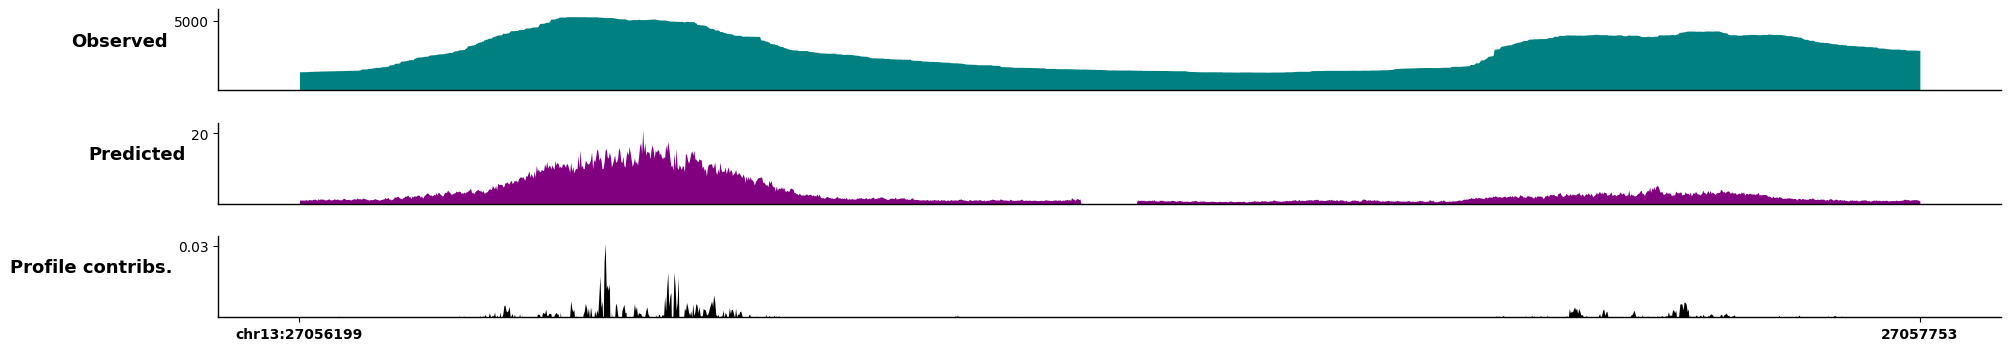

In [21]:
# Define upstream of prolactin regions
regions_to_plot = [
    ("Upstream Prolactin", "chr13", 27056199, 27057753)
]

# Plot
plot_minimal_locus(
    regions_to_plot,
    observed_bw,
    predicted_bw,
    contribs_bw,
    out_name='/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/locus_plots/mm10_upstream_prl_2.svg'
)

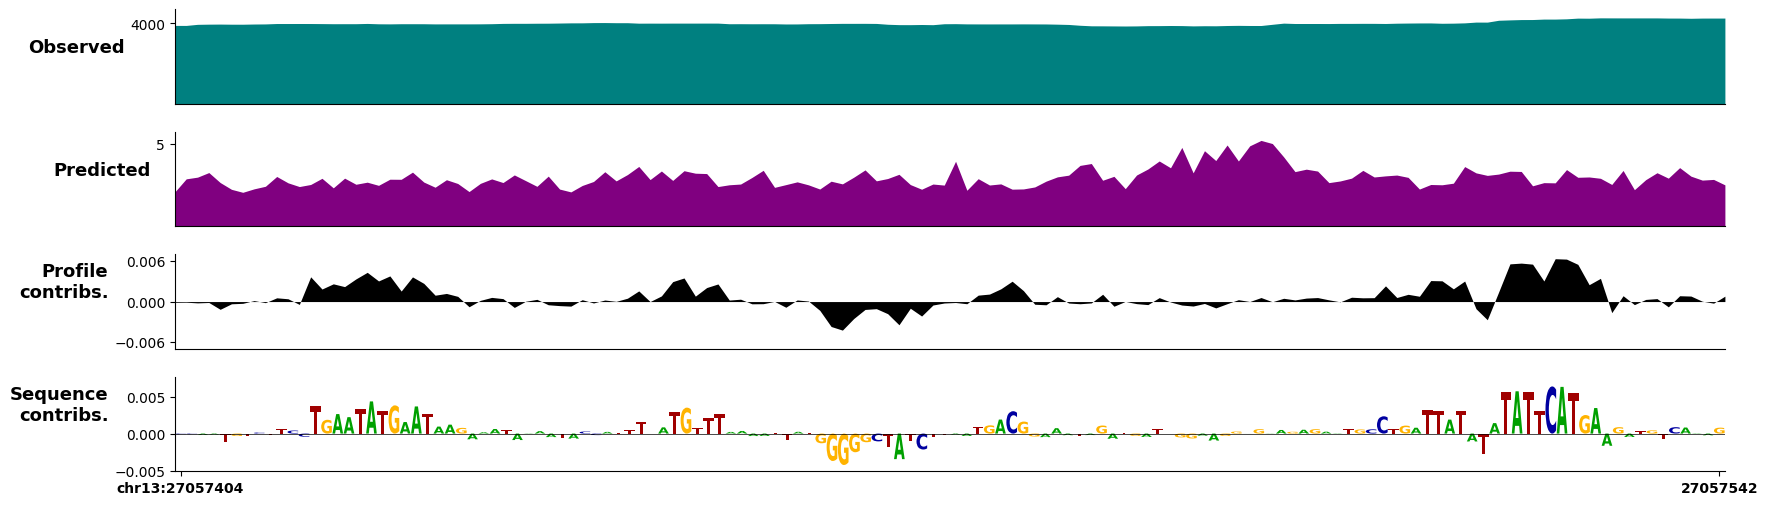

In [28]:
regions_to_plot = [
    ("Proximal Region", "chr13", 27057404, 27057542)
]

# Plot
plot_advanced_locus(
    regions_to_plot,
    observed_bw,
    predicted_bw,
    contribs_bw,
    fasta_path,
    out_name='/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/locus_plots/mm10_proximal_region_prl_2.svg'
)

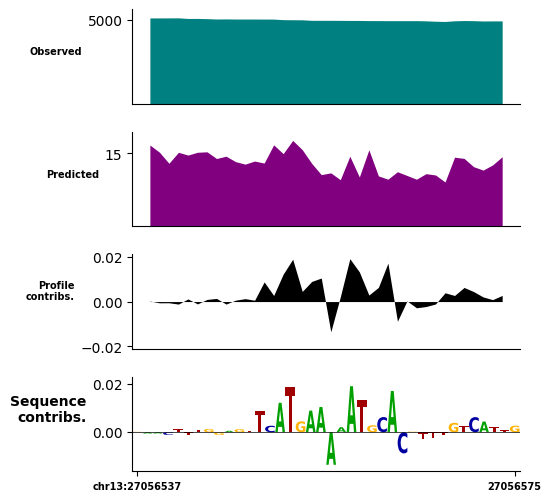

In [29]:
regions_to_plot = [
    ("SiteB", "chr13", 27056537, 27056575)
]

# Plot
plot_advanced_small_region(
    regions_to_plot,
    observed_bw,
    predicted_bw,
    contribs_bw,
    fasta_path,
    out_name='/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/locus_plots/mm10_siteB_regions.svg'
)

### <div style = 'background-color:PapayaWhip'> **rn6 _Prl_ locus plots**</div>

In [31]:
# Paths for plotting upstream of Prolactin in mm10 Lactotrophs

base_dir = '/scratch/prj/stem_cells_pituitary'
data_dir = f'{base_dir}/Georgia/ChromBPnet/outputs/experiments/'

fasta_path = f'{base_dir}/Georgia/genome/rn6/rn6.fa'

contribs_bw = f'{data_dir}/experiment_24_CTRL/contribs_bw/experiment_24_CTRL_exp24_consensus_peaks_modified_contribs.profile_scores.bw'
observed_bw = f'{base_dir}/Bence/atacseq_results/24/bwa/merged_replicate/bigwig/CTRL.mRp.clN.bigWig'
predicted_bw = f'{data_dir}/experiment_24_CTRL/pred_bw/experiment_24_CTRL_predicted_chrombpnet_nobias.bw'

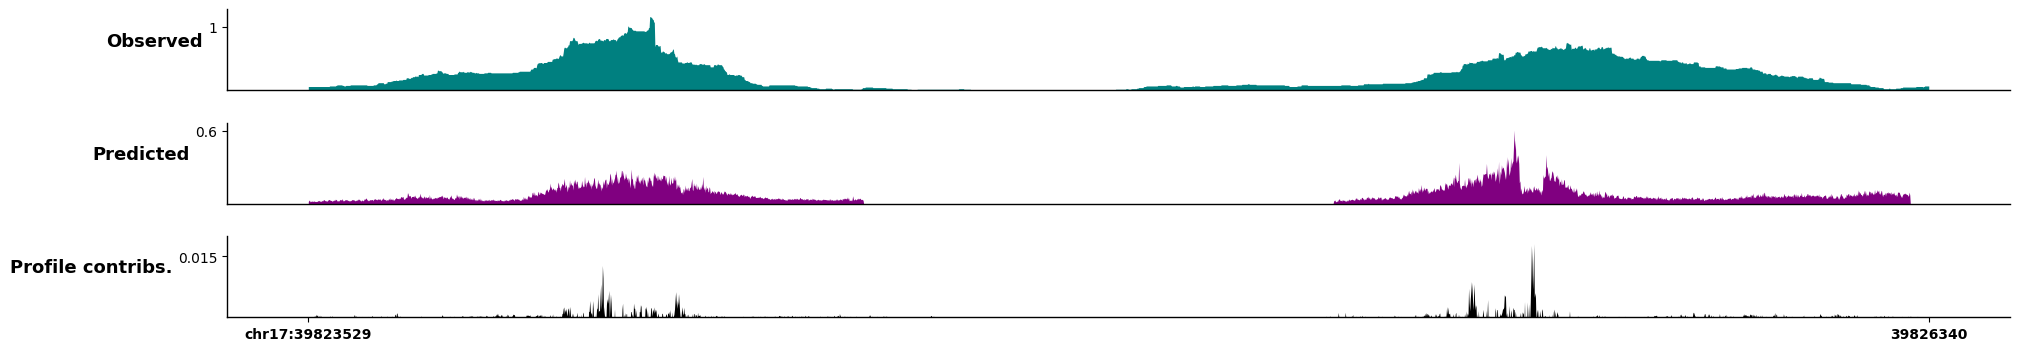

In [33]:
# Define upstream of prolactin regions
regions_to_plot = [
    ("Upstream Prolactin", "chr17", 39823529, 39826340)
]

plot_minimal_locus_flipped(
    regions_to_plot,
    observed_bw,
    predicted_bw,
    contribs_bw,
    out_name='/users/k25055720/rn6_upstream_prl_flipped.svg'
    #out_name='/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/locus_plots/rn6_upstream_prl_flipped.png'
)

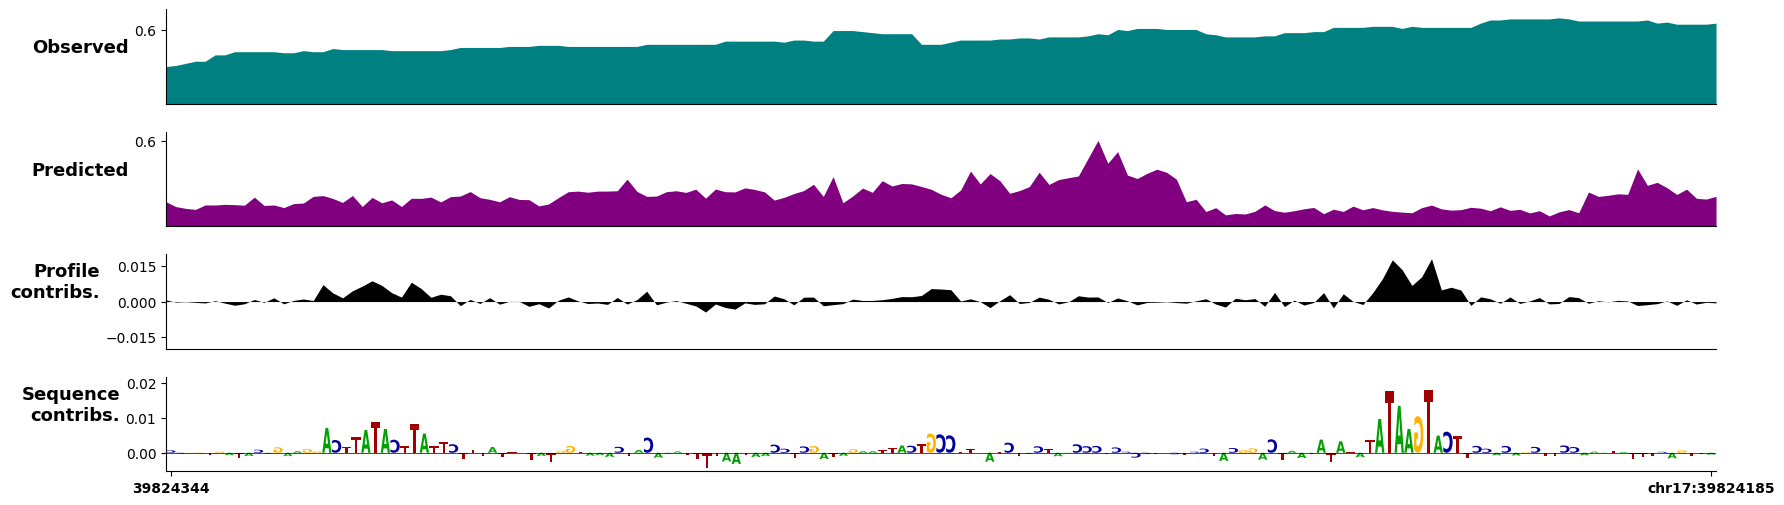

In [34]:
regions_to_plot = [
    ("Proximal Region", "chr17", 39824185, 39824344)
]

# Plot
plot_advanced_locus_flipped(
    regions_to_plot,
    observed_bw,
    predicted_bw,
    contribs_bw,
    fasta_path,
    out_name='/users/k25055720/rn6_proximal_region_prl.svg'
    #out_name='/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/locus_plots/rn6_proximal_region_prl.svg'
)

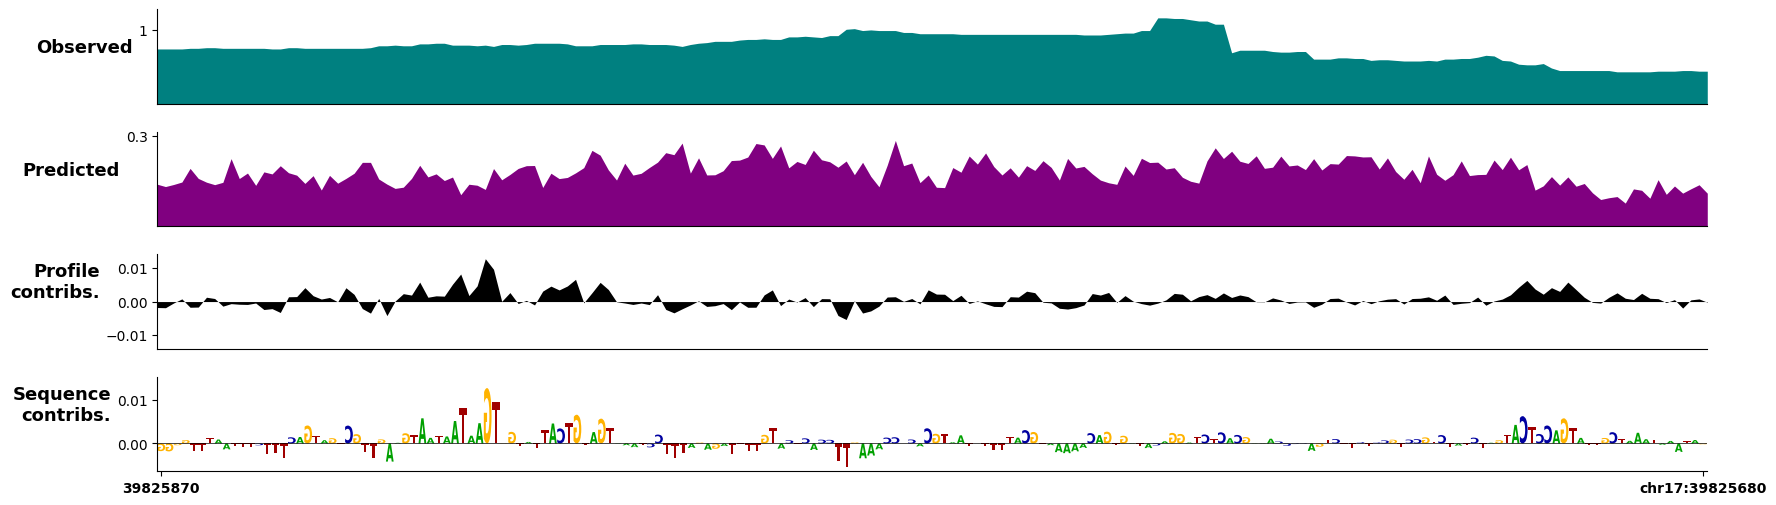

In [35]:
regions_to_plot = [
    ("Distal Region", "chr17", 39825680, 39825870)
]

# Plot
plot_advanced_locus_flipped(
    regions_to_plot,
    observed_bw,
    predicted_bw,
    contribs_bw,
    fasta_path,
    out_name='/users/k25055720/rn6_distal_region_prl.svg'
    #out_name='/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/locus_plots/rn6_distal_region_prl.svg'
)

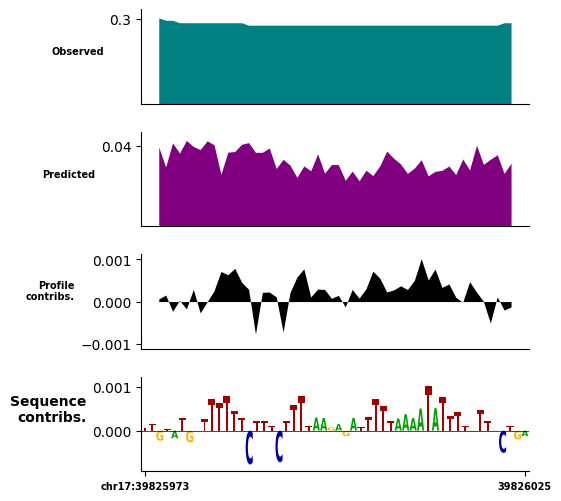

In [36]:
regions_to_plot = [
    ("SiteG", "chr17", 39825973, 39826025)
]

# Plot
plot_advanced_small_region(
    regions_to_plot,
    observed_bw,
    predicted_bw,
    contribs_bw,
    fasta_path,
    out_name='/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/locus_plots/rn6_siteG_regions.svg'
)

### <div style = 'background-color:PapayaWhip'> **GH3 _Prl_ locus plots**</div>

In [38]:
# Normal Paths
base_dir = '/scratch/prj/stem_cells_pituitary'
data_dir = f'{base_dir}/Georgia/ChromBPnet/outputs/experiments/'
fasta_path = f'{base_dir}/Georgia/genome/rn6/rn6.fa'

In [44]:
# CTRL
contribs_bw = f'{data_dir}/experiment_24_CTRL/contribs_bw/experiment_24_CTRL_exp24_consensus_peaks_modified_contribs.profile_scores.bw'
observed_bw = f'{base_dir}/Bence/atacseq_results/24/bwa/merged_replicate/bigwig/CTRL.mRp.clN.bigWig'
predicted_bw = f'{data_dir}/experiment_24_CTRL/pred_bw/experiment_24_CTRL_predicted_chrombpnet_nobias.bw'

In [47]:
# SOX2
contribs_bw = f'{data_dir}/experiment_24_SOX2/contribs_bw/experiment_24_SOX2_exp24_consensus_peaks_modified_contribs.profile_scores.bw'
observed_bw = f'{base_dir}/Bence/atacseq_results/24/bwa/merged_replicate/bigwig/SOX2.mRp.clN.bigWig'
predicted_bw = f'{data_dir}/experiment_24_SOX2/pred_bw/experiment_24_SOX2_predicted_chrombpnet_nobias.bw'

In [49]:
# AB
contribs_bw = f'{data_dir}/experiment_24_AB/contribs_bw/experiment_24_AB_exp24_consensus_peaks_modified_contribs.profile_scores.bw'
observed_bw = f'{base_dir}/Bence/atacseq_results/24/bwa/merged_replicate/bigwig/AB.mRp.clN.bigWig'
predicted_bw = f'{data_dir}/experiment_24_AB/pred_bw/experiment_24_AB_predicted_chrombpnet_nobias.bw'

In [51]:
# ABS
contribs_bw = f'{data_dir}/experiment_24_ABS/contribs_bw/experiment_24_ABS_exp24_consensus_peaks_modified_contribs.profile_scores.bw'
observed_bw = f'{base_dir}/Bence/atacseq_results/24/bwa/merged_replicate/bigwig/ABS.mRp.clN.bigWig'
predicted_bw = f'{data_dir}/experiment_24_ABS/pred_bw/experiment_24_ABS_predicted_chrombpnet_nobias.bw'

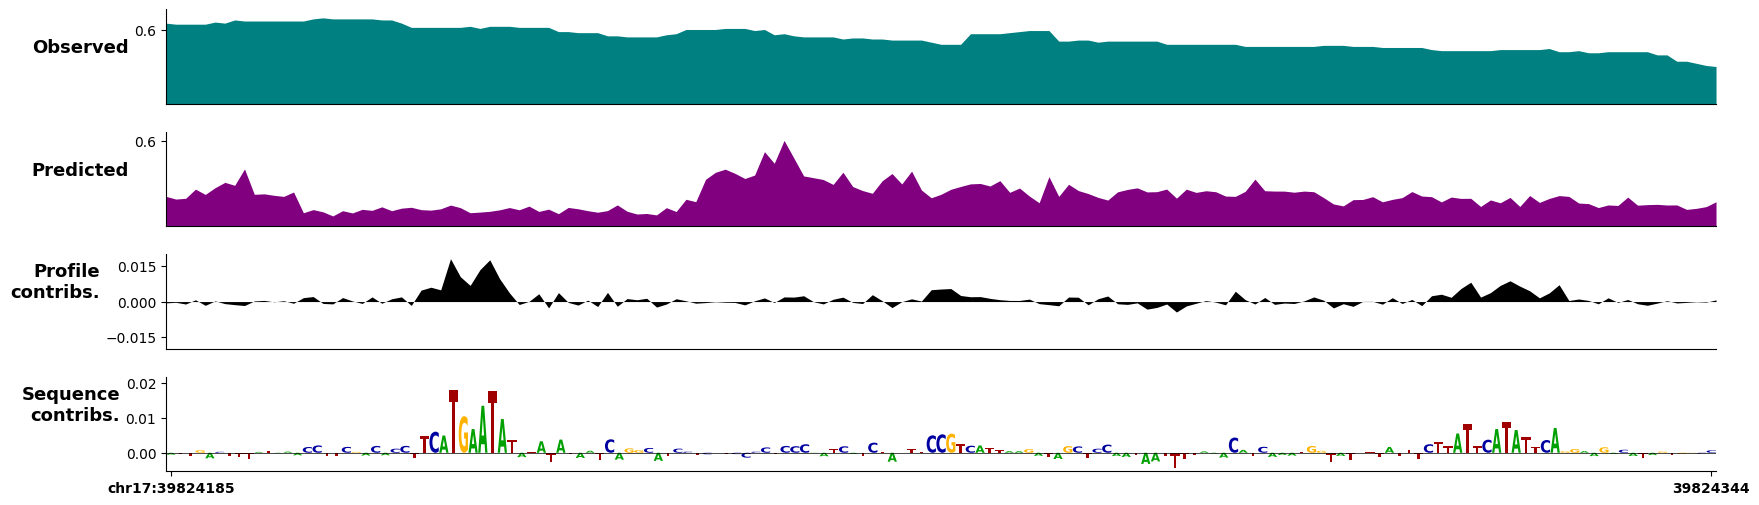

In [45]:
regions_to_plot = [
    ("Proximal Region", "chr17", 39824185, 39824344)
]

# Plot
plot_advanced_locus(
    regions_to_plot,
    observed_bw,
    predicted_bw,
    contribs_bw,
    fasta_path,
    out_name='/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/locus_plots/GH3_CTRL_upstream_prl.svg'
)

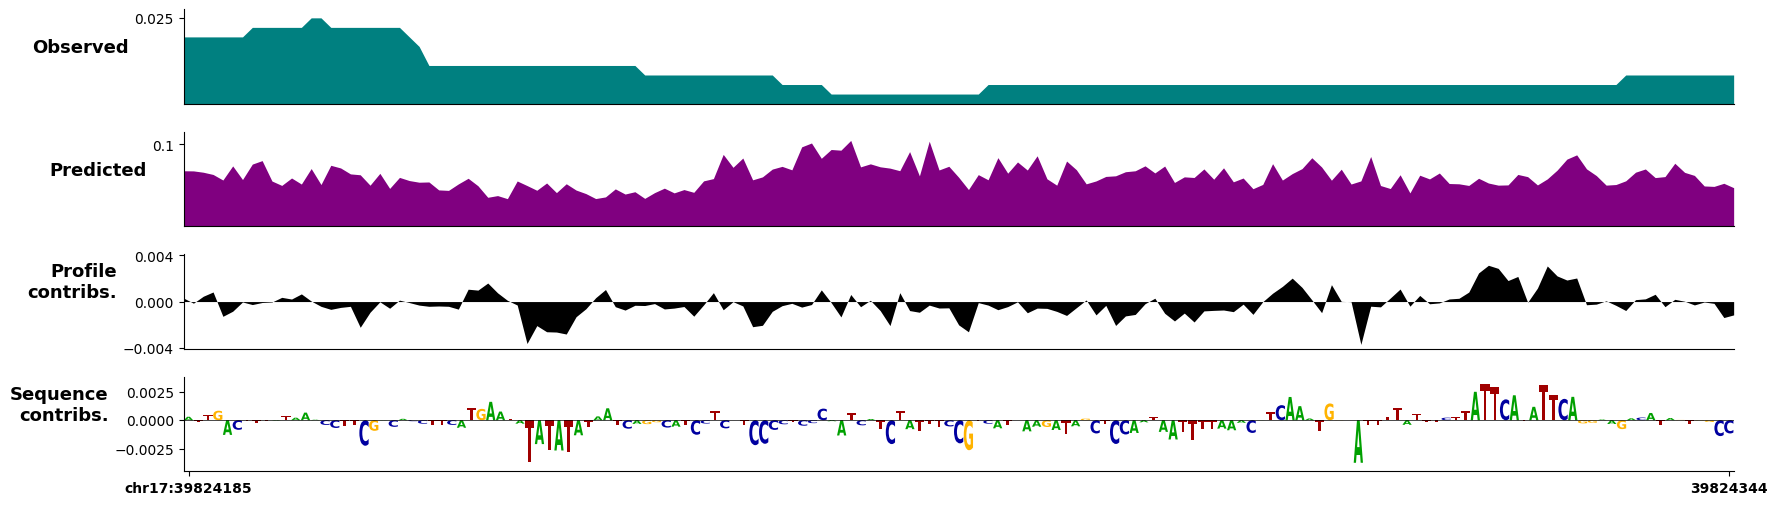

In [48]:
regions_to_plot = [
    ("Proximal Region", "chr17", 39824185, 39824344)
]

# Plot
plot_advanced_locus(
    regions_to_plot,
    observed_bw,
    predicted_bw,
    contribs_bw,
    fasta_path,
    out_name='/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/locus_plots/GH3_SOX2_upstream_prl.svg'
)

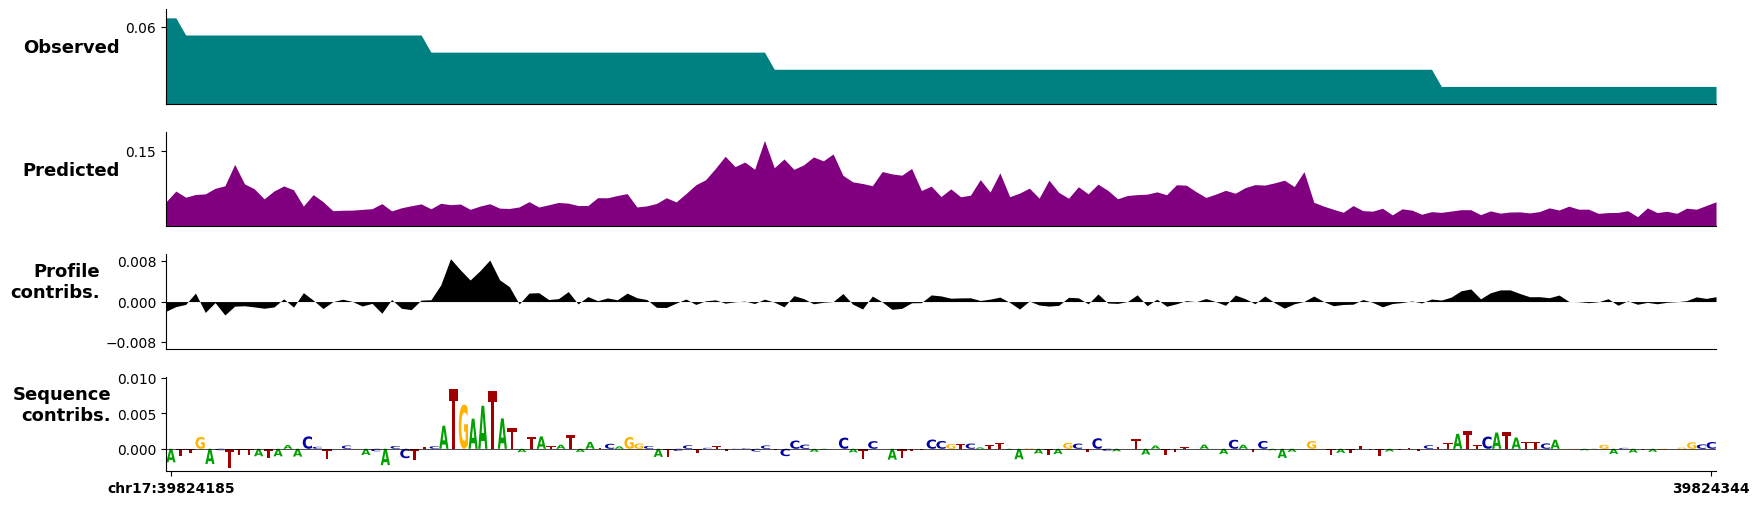

In [50]:
regions_to_plot = [
    ("Proximal Region", "chr17", 39824185, 39824344)
]

# Plot
plot_advanced_locus(
    regions_to_plot,
    observed_bw,
    predicted_bw,
    contribs_bw,
    fasta_path,
    out_name='/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/locus_plots/GH3_AB_upstream_prl.svg'
)

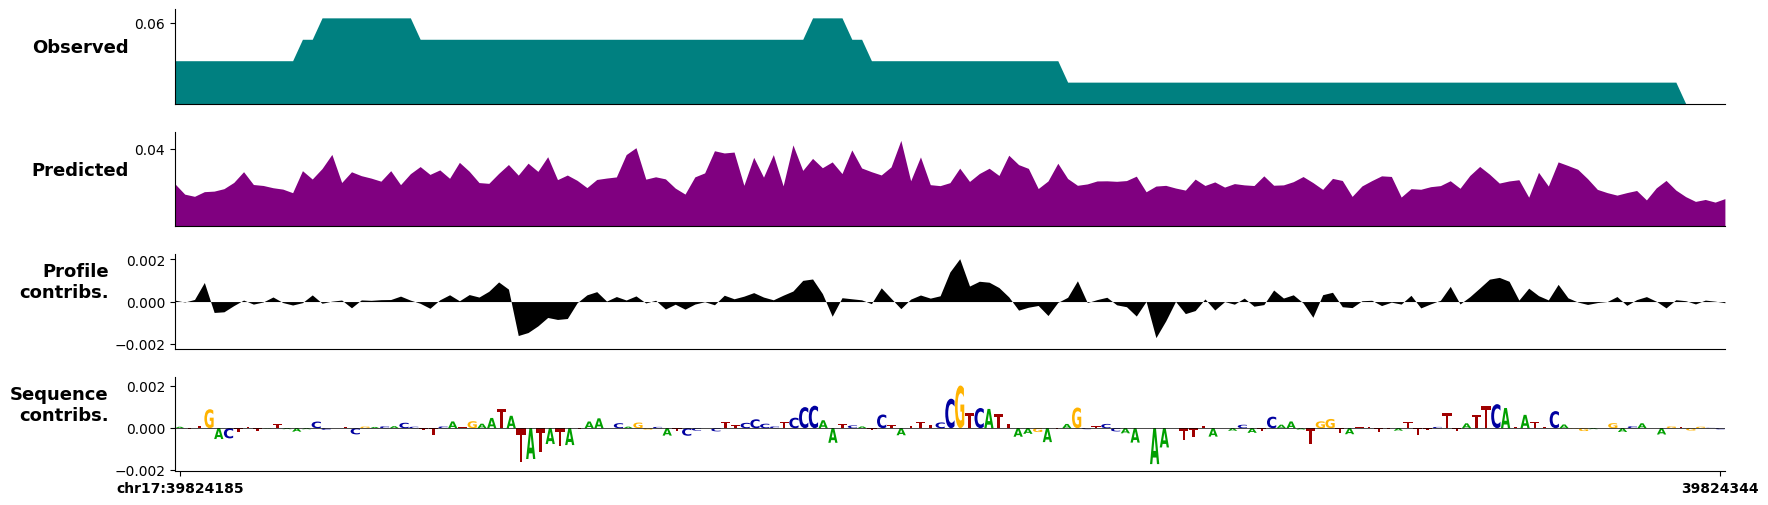

In [52]:
regions_to_plot = [
    ("Proximal Region", "chr17", 39824185, 39824344)
]

# Plot
plot_advanced_locus(
    regions_to_plot,
    observed_bw,
    predicted_bw,
    contribs_bw,
    fasta_path,
    out_name='/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/locus_plots/GH3_ABS_upstream_prl.svg'
)

### <div style = 'background-color:PapayaWhip'> **ChromBPNet vs BPNet Validation**</div>

In [53]:
# Paths
exp_dir  = '/scratch/prj/stem_cells_pituitary/Georgia/bpnet/exp20_CUTandRUN_PIT1_chr13'
prefix   = f'{exp_dir}/exp20_PIT1'

attr_npz = f'{prefix}.attributions.attr.npz'
ohe_npz  = f'{prefix}.attributions.ohe.npz'
peaks_bed = '/scratch/prj/stem_cells_pituitary/Bence/cutandrun_results/20/03_peak_calling/05_consensus_peaks/PIT1.seacr.consensus.peaks.awk.bed'
obs_bw   = '/scratch/prj/stem_cells_pituitary/Bence/cutandrun_results/20/03_peak_calling/03_bed_to_bigwig/PIT1_R1.bigWig'

BASES         = ['A', 'C', 'G', 'T']
LETTER_COLORS = {'A': '#00A000', 'C': '#0000A0', 'G': '#FFB300', 'T': '#A00000'}
VAL_CHROMS    = ['chr8', 'chr13']

In [54]:
seqlets = pd.read_csv(
    '/scratch/prj/stem_cells_pituitary/Georgia/bpnet/exp20_CUTandRUN_PIT1_chr13/exp20_PIT1.seqlets.bed',
    sep='\t', header=None
)
print(seqlets.head())
print(seqlets[0].unique())

# Filter to chr8
chr13_seqlets = seqlets[seqlets[0] == 'chr13']
print(f"\n{len(chr13_seqlets)} seqlets on chr13")
print(chr13_seqlets.head(20))

       0          1          2         3             4
0   chr8   64941986   64942017  0.204398  9.753057e-10
1   chr8   17972598   17972629  0.198218  1.783247e-04
2   chr8   49039513   49039544  0.180737  7.048023e-05
3   chr8   56010863   56010890  0.179562  1.965860e-03
4  chr13  100842604  100842634  0.178432  1.688995e-03
['chr8' 'chr13']

35988 seqlets on chr13
        0          1          2         3             4
4   chr13  100842604  100842634  0.178432  1.688995e-03
5   chr13   78453533   78453564  0.178187  1.276991e-08
7   chr13   10868752   10868783  0.171761  2.396619e-05
8   chr13   71770977   71771003  0.163237  1.721352e-04
11  chr13   59096035   59096066  0.160637  2.617872e-05
12  chr13  106715294  106715325  0.159700  4.266579e-03
13  chr13   30760007   30760037  0.159555  8.121876e-04
15  chr13    6579934    6579961  0.153936  4.639295e-04
16  chr13   60601910   60601936  0.149389  1.065901e-03
17  chr13   17581308   17581338  0.148523  3.711277e-03
18  chr13  10

In [55]:
# BPNet seqlets (chr8/chr13 only)
seqlets = pd.read_csv(
    '/scratch/prj/stem_cells_pituitary/Georgia/bpnet/exp20_CUTandRUN_PIT1_chr13/exp20_PIT1.seqlets.bed',
    sep='\t', header=None,
    names=['chrom', 'start', 'end', 'score', 'pval']
)
print(f"Total BPNet seqlets: {len(seqlets)}")
print(f"Chroms: {seqlets['chrom'].unique()}")

# Check what signal ChromBPNet has at each BPNet seqlet location
contribs_bw = '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/Lactotrophs/contribs_bw/Lactotrophs_contribs.profile_scores.bw'

with pyBigWig.open(contribs_bw) as bw:
    chrombpnet_chroms = list(bw.chroms().keys())
    print(f"\nChroms in ChromBPNet bigwig: {chrombpnet_chroms}")
    
    # Check if chr8/chr13 exist in the ChromBPNet bigwig at all
    print(f"chr8 in ChromBPNet: {'chr8' in chrombpnet_chroms}")
    print(f"chr13 in ChromBPNet: {'chr13' in chrombpnet_chroms}")

Total BPNet seqlets: 81640
Chroms: ['chr8' 'chr13']

Chroms in ChromBPNet bigwig: ['chr1', 'chr2', 'chrX', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr10', 'chr8', 'chr14', 'chr9', 'chr11', 'chr13', 'chr12', 'chr15', 'chr16', 'chr17', 'chrY', 'chr18', 'chr19']
chr8 in ChromBPNet: True
chr13 in ChromBPNet: True


In [56]:
# For each BPNet seqlet, get the mean ChromBPNet contribution score at that location
def get_mean_signal(bw_path, chrom, start, end):
    try:
        with pyBigWig.open(bw_path) as bw:
            vals = bw.values(chrom, start, end)
            if vals is None:
                return 0.0
            return np.nanmean(np.abs(vals))
    except:
        return 0.0

# Score each seqlet - only chr8/chr14 since that's where BPNet attributions are
seqlets_val = seqlets[seqlets['chrom'].isin(['chr8', 'chr13'])].copy()

seqlets_val['chrombpnet_signal'] = seqlets_val.apply(
    lambda r: get_mean_signal(contribs_bw, r['chrom'], r['start'], r['end']),
    axis=1
)

# Sort by both scores to find regions both models agree on
seqlets_val['bpnet_score'] = seqlets_val['score']
seqlets_val['combined'] = seqlets_val['bpnet_score'] * seqlets_val['chrombpnet_signal']

top_overlap = seqlets_val[seqlets_val['chrombpnet_signal'] > 0].sort_values('combined', ascending=False)

print(f"\nSeqlets with ChromBPNet signal: {len(top_overlap)}")
print(top_overlap[['chrom', 'start', 'end', 'bpnet_score', 'chrombpnet_signal']].head(20))

/tmp/ipykernel_4101191/2436083212.py:8: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.abs(vals))



Seqlets with ChromBPNet signal: 24745
       chrom      start        end  bpnet_score  chrombpnet_signal
12550  chr13  100939835  100939848     0.028721           0.033002
2352    chr8   13292572   13292591     0.050803           0.018560
15817   chr8   68233197   68233211     0.026162           0.034119
10996   chr8  109536897  109536912     0.030284           0.026637
13586  chr13   69461129   69461143     0.027820           0.025070
13304   chr8  125719127  125719141     0.028063           0.021878
38792   chr8  107386800  107386813     0.016739           0.035716
9283   chr13   42623653   42623667     0.032296           0.017520
8965    chr8   68876083   68876096     0.032760           0.017197
212     chr8   29460222   29460247     0.094015           0.005946
20108   chr8   84024360   84024373     0.023590           0.023466
29685   chr8   57429392   57429403     0.019597           0.027994
478     chr8   93624249   93624266     0.078769           0.006893
11735   chr8   40151067

In [57]:
CHROM, START, END = 'chr8', 113432480, 113432535

In [58]:
# Load peaks - filter to validation chroms only (these map 1:1 to attribution arrays)
peaks = pd.read_csv(peaks_bed, sep='\t', header=None)
peaks_val = peaks[peaks[0].isin(VAL_CHROMS)].reset_index(drop=True)
print(f"Validation peaks: {len(peaks_val)}")  # expect 3105

# Load attribution arrays  (N, 4, L) → transpose to (N, L, 4)
attr_arr = np.load(attr_npz)['arr_0'].transpose(0, 2, 1)  # (N, L, 4)
ohe_arr  = np.load(ohe_npz) ['arr_0'].transpose(0, 2, 1)  # (N, L, 4)
L = attr_arr.shape[1]  # 2114
print(f"Attribution array shape: {attr_arr.shape}")

query_mid = (START + END) // 2
best_row, best_dist = None, np.inf

for row_i, (_, peak) in enumerate(peaks_val.iterrows()):
    if peak[0] != CHROM:
        continue
    pmid = (peak[1] + peak[2]) // 2
    dist = abs(pmid - query_mid)
    if dist < best_dist:
        best_dist  = dist
        best_row   = row_i
        peak_start = peak[1]
        peak_end   = peak[2]

print(f"Best peak: row {best_row}, {CHROM}:{peak_start}-{peak_end}, dist={best_dist}")

# BPNet centres the 2114bp window on the peak centre
peak_mid    = (peak_start + peak_end) // 2
win_start   = peak_mid - L // 2   # genomic start of the 2114bp window
win_end     = win_start + L

s_idx = max(START - win_start, 0)
e_idx = min(END   - win_start, L)
print(f"Window: {CHROM}:{win_start}-{win_end}, slicing [{s_idx}:{e_idx}]")

attr_slice = attr_arr[best_row, s_idx:e_idx, :]  # (w, 4)
ohe_slice  = ohe_arr [best_row, s_idx:e_idx, :]  # (w, 4)

# Per-position contribution = sum(attribution * one_hot)
contrib = (attr_slice * ohe_slice).sum(axis=1)    # (w,)
seq_str = ''.join(BASES[np.argmax(ohe_slice[i])] for i in range(len(ohe_slice)))

print(f"Contrib range: {contrib.min():.4f} to {contrib.max():.4f}")
print(f"Sequence snippet: {seq_str[:30]}...")

# Observed signal 
with pyBigWig.open(obs_bw) as bw:
    obs_signal = np.nan_to_num(bw.values(CHROM, START, END))

# Draw sequence contribution letters
def draw_seq_contrib(ax, sequence, contrib_scores):
    n = len(sequence)
    matrix = np.zeros((n, 4))
    for xi, (base, score) in enumerate(zip(sequence, contrib_scores)):
        if base in BASES:
            matrix[xi, BASES.index(base)] = score
    df     = pd.DataFrame(matrix, columns=BASES)
    df_pos = df.clip(lower=0)
    df_neg = df.clip(upper=0)
    if df_pos.abs().sum().sum() > 0:
        logomaker.Logo(df_pos, ax=ax, color_scheme=LETTER_COLORS, baseline_width=0)
    if df_neg.abs().sum().sum() > 0:
        logomaker.Logo(df_neg, ax=ax, color_scheme=LETTER_COLORS,
                       baseline_width=0, flip_below=False)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlim(-0.5, n - 0.5)
    pos_max = df_pos.sum(axis=1).max() or 1e-9
    neg_min = df_neg.sum(axis=1).min() or -1e-9
    ax.set_ylim(neg_min * 1.2, pos_max * 1.2)

Validation peaks: 3901
Attribution array shape: (3901, 2114, 4)
Best peak: row 3644, chr8:113428900-113436850, dist=368
Window: chr8:113431818-113433932, slicing [662:717]
Contrib range: -0.0056 to 0.0142
Sequence snippet: GCTCCGCCCTGAGGCTGCTGCAAATGTATT...


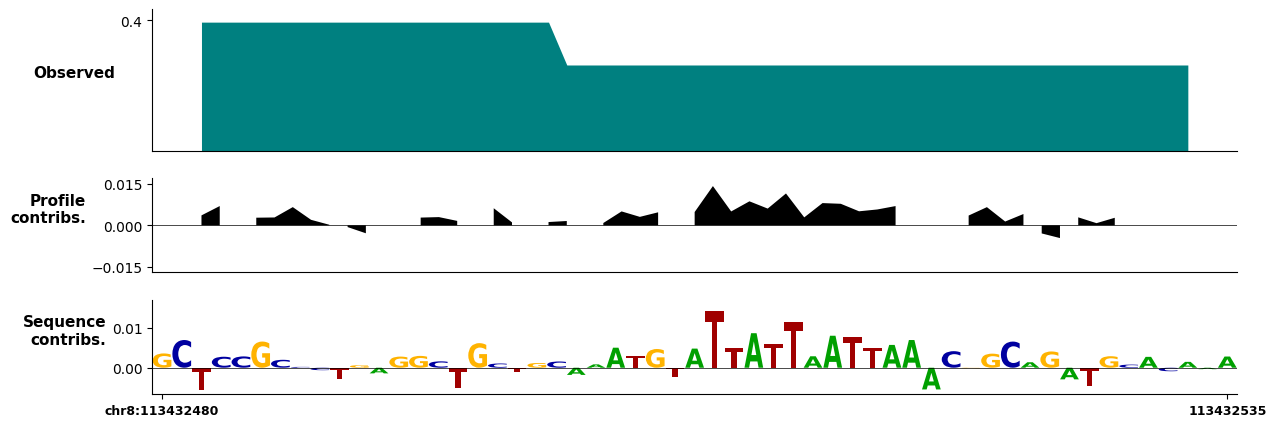

In [59]:
fig, axes = plt.subplots(3, 1, figsize=(14, 5),
                         gridspec_kw={'height_ratios': [1.5, 1, 1]})

# Observed
ax = axes[0]
ax.fill_between(np.arange(len(obs_signal)), obs_signal, color='teal', lw=0)
ax.set_ylabel('Observed', rotation=0, ha='right', fontweight='bold', fontsize=11)
ax.set_xticks([])
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, obs_signal.max() * 1.1)
ax.yaxis.set_major_locator(MaxNLocator(1, prune='lower'))

# Profile contributions (filled area, same data as sequence contribs)
ax = axes[1]
x = np.arange(len(contrib))
ax.fill_between(x, contrib, where=contrib >= 0, color='black', lw=0)
ax.fill_between(x, contrib, where=contrib <  0, color='black', lw=0)
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Profile\ncontribs.', rotation=0, ha='right', fontweight='bold', fontsize=11)
ax.set_xticks([])
ax.spines[['top', 'right']].set_visible(False)
ymax = np.abs(contrib).max()
ax.set_ylim(-ymax * 1.2, ymax * 1.2)
ax.yaxis.set_major_locator(MaxNLocator(2, prune='lower'))

# Sequence contributions (letters) 
ax = axes[2]
draw_seq_contrib(ax, seq_str, contrib)
ax.set_ylabel('Sequence\ncontribs.', rotation=0, ha='right', fontweight='bold', fontsize=11)
ax.set_xticks([0, len(seq_str) - 1])
ax.set_xticklabels([f'{CHROM}:{START}', str(END)], fontsize=9, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.subplots_adjust(hspace=0.25)
out = f'{exp_dir}/locus_PIT1_{CHROM}_{START}_{END}.svg'
plt.savefig(out, format='svg', bbox_inches='tight')
plt.show()

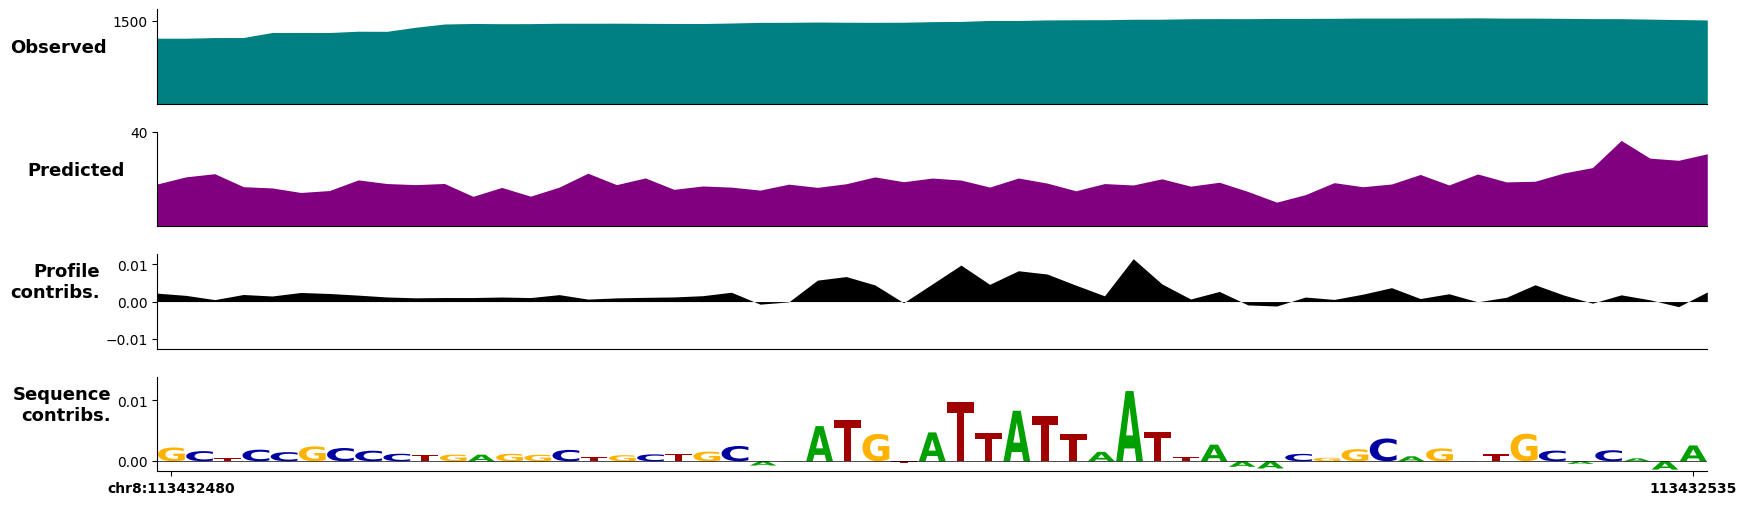

In [60]:
# Match location with mm10 model
# Paths for plotting upstream of Prolactin in mm10 Lactotrophs

base_dir = '/scratch/prj/stem_cells_pituitary'
data_dir = f'{base_dir}/Georgia/ChromBPnet/outputs/mouse/'

fasta_path = f'{base_dir}/Georgia/genome/mm10/mm10.fa'

contribs_bw = f'{data_dir}/Lactotrophs/contribs_bw/Lactotrophs_contribs.profile_scores.bw'
observed_bw = f'{data_dir}/Lactotrophs/Lactotrophs_observed.bw'
predicted_bw = f'{data_dir}/Lactotrophs/pred_bw/Lactotrophs_predicted_chrombpnet_nobias.bw'


regions_to_plot = [
    ("validation location", 'chr8', 113432480, 113432535)
]

# Plot
plot_advanced_locus(
    regions_to_plot,
    observed_bw,
    predicted_bw,
    contribs_bw,
    fasta_path,
    out_name='/scratch/prj/stem_cells_pituitary/Georgia/bpnet/exp20_CUTandRUN_PIT1_chr13/mm10_valid_region.svg'
)